# Pagaya Technologies Ltd. (NASDAQ: PGY) — Financial Model

*March 2026 | All monetary values in USD thousands unless noted*

In [1]:
# ============================================================
# CELL GROUP 1: SETUP & DATA INPUT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Color palette
COLORS = {
    'primary': '#1a73e8',
    'secondary': '#34a853',
    'accent': '#ea4335',
    'neutral': '#5f6368',
    'light': '#a8d5e2',
    'gold': '#f9ab00',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Annual Income Statement ($thousands) ─────────────────────
# Sources: PGY 10-K filings and earnings releases (FY2022-FY2025)
# Note: 1-for-12 reverse split effective March 8, 2024; all share counts adjusted

income_data = {
    'Year':                       [2022,       2023,       2024,       2025],
    'Revenue_from_fees':          [685_400,    772_800,  1_004_600,  1_250_000],
    'Interest_income':            [ 57_800,     38_700,     22_600,     41_000],
    'Investment_income':          [  5_800,        500,      5_000,     10_000],
    'Total_revenue':              [748_900,    812_100,  1_032_200,  1_301_000],
    'Production_costs':           [451_100,    508_900,    597_700,    789_000],
    'FRLPC':                      [234_300,    263_900,    406_900,    512_000],
    'Tech_data_product':          [150_900,     74_400,     64_000,     55_000],
    'Sales_marketing':            [104_200,     49_800,     38_000,     32_000],
    'General_admin':              [294_200,    203_400,    265_700,    160_000],
    'Total_opex':                 [1_000_400,  836_500,    965_400,  1_036_000],
    'Operating_income':           [-251_500,   -24_400,     66_800,    264_000],
    'GAAP_net_income':            [-302_300,  -128_400,   -401_400,     81_000],
    'Adjusted_EBITDA':            [  -4_800,    82_000,    210_400,    371_000],
    'Adjusted_net_income':        [ -32_700,    16_600,     66_900,    275_000],
    'Basic_EPS':                  [  -5.27,     -2.10,      -5.40,       0.99],
    'Diluted_EPS':                [  -5.27,     -2.10,      -5.40,       0.93],
    'WA_basic_shares':            [ 57_350,    61_292,     74_300,     78_000],
    'WA_diluted_shares':          [ 57_350,    61_292,     74_300,     83_000],
}

historical_annual = pd.DataFrame(income_data).set_index('Year')

# Derived metrics
historical_annual['Revenue_M'] = historical_annual['Total_revenue'] / 1000
historical_annual['FRLPC_M'] = historical_annual['FRLPC'] / 1000
historical_annual['Adj_EBITDA_M'] = historical_annual['Adjusted_EBITDA'] / 1000
historical_annual['YoY_Growth'] = historical_annual['Total_revenue'].pct_change()
historical_annual['FRLPC_margin_pct'] = historical_annual['FRLPC'] / historical_annual['Total_revenue'] * 100
historical_annual['Adj_EBITDA_margin_pct'] = historical_annual['Adjusted_EBITDA'] / historical_annual['Total_revenue'] * 100
historical_annual['Opex_ex_production'] = (historical_annual['Tech_data_product'] + 
                                            historical_annual['Sales_marketing'] + 
                                            historical_annual['General_admin'])

print('Annual Income Statement loaded.')
display_cols = ['Total_revenue', 'Production_costs', 'FRLPC', 'Opex_ex_production',
                'Operating_income', 'GAAP_net_income', 'Adjusted_EBITDA']
display_df = historical_annual[display_cols].copy()
display_df.columns = ['Revenue', 'Prod. Costs', 'FRLPC', 'OpEx (ex-prod)', 
                       'Oper. Income', 'GAAP Net Inc', 'Adj EBITDA']
print(display_df.to_string())

Annual Income Statement loaded.
      Revenue  Prod. Costs   FRLPC  OpEx (ex-prod)  Oper. Income  GAAP Net Inc  Adj EBITDA
Year                                                                                      
2022   748900       451100  234300          549300       -251500       -302300       -4800
2023   812100       508900  263900          327600        -24400       -128400       82000
2024  1032200       597700  406900          367700         66800       -401400      210400
2025  1301000       789000  512000          247000        264000         81000      371000


In [3]:
# ── Expense Breakdown ($thousands) ──────────────────────────
# Operating expenses by category (excluding production costs)

expense_data = {
    'Year':                 [2022,       2023,       2024,       2025],
    'Production_costs':     [451_100,    508_900,    597_700,    789_000],
    'Technology_R_D':       [150_900,     74_400,     64_000,     55_000],
    'Sales_Marketing':      [104_200,     49_800,     38_000,     32_000],
    'G_and_A':              [294_200,    203_400,    265_700,    160_000],
    'SBC_estimate':         [120_000,     80_000,    280_000,     60_000],
    'D_and_A':              [  8_000,     10_000,     12_000,     14_000],
}

expenses = pd.DataFrame(expense_data).set_index('Year')
expenses['Total_OpEx'] = expenses.sum(axis=1) - expenses['SBC_estimate'] - expenses['D_and_A']  # avoid double count
expenses['Cash_OpEx_ex_prod'] = expenses['Technology_R_D'] + expenses['Sales_Marketing'] + expenses['G_and_A'] - expenses['SBC_estimate']

# SBC as % of revenue
expenses['Revenue'] = historical_annual['Total_revenue'].values
expenses['SBC_pct_rev'] = expenses['SBC_estimate'] / expenses['Revenue'] * 100

print('Expense Breakdown:')
print(expenses[['Production_costs', 'Technology_R_D', 'Sales_Marketing', 'G_and_A', 'SBC_estimate']].to_string())
print(f"\nSBC as % of Revenue: {expenses['SBC_pct_rev'].to_dict()}")

Expense Breakdown:
      Production_costs  Technology_R_D  Sales_Marketing  G_and_A  SBC_estimate
Year                                                                          
2022            451100          150900           104200   294200        120000
2023            508900           74400            49800   203400         80000
2024            597700           64000            38000   265700        280000
2025            789000           55000            32000   160000         60000

SBC as % of Revenue: {2022: 16.023501134997996, 2023: 9.851003570988794, 2024: 27.126525867080026, 2025: 4.611837048424289}


In [4]:
# ── Balance Sheet ($thousands) ───────────────────────────────

balance_sheet_data = {
    'Year':                      [2022,       2023,       2024,       2025],
    'Cash_equivalents':          [309_800,    186_500,    187_900,    235_000],
    'Restricted_cash':           [ 27_300,     36_100,     42_000,     53_000],
    'Investments_loans_sec':     [463_000,    716_800,    764_100,    945_000],
    'Other_current_assets':      [ 82_700,     80_500,     55_100,     68_000],
    'Total_current_assets':      [419_800,    303_400,    285_000,    356_000],
    'Total_assets':              [1_045_100, 1_208_400, 1_291_100, 1_546_000],
    'Secured_borrowing':         [139_600,    271_700,    163_700,    194_000],
    'Revolving_credit':          [ 15_000,     90_000,          0,          0],
    'Long_term_debt':            [      0,          0,    303_600,    482_000],
    'Exchangeable_notes':        [      0,          0,    146_300,    149_000],
    'Total_debt':                [154_600,    361_700,    613_600,    825_000],
    'Total_current_liabilities': [128_000,     74_900,    157_800,    186_000],
    'Total_liabilities':         [279_700,    468_400,    849_600,    960_000],
    'Total_equity':              [765_400,    665_700,    441_500,    480_000],
}

balance_sheet = pd.DataFrame(balance_sheet_data).set_index('Year')
balance_sheet['Net_debt'] = balance_sheet['Total_debt'] - balance_sheet['Cash_equivalents']
balance_sheet['Debt_to_equity'] = balance_sheet['Total_debt'] / balance_sheet['Total_equity']
balance_sheet['Leverage_ratio'] = balance_sheet['Total_debt'] / balance_sheet['Total_assets']

print('Balance Sheet Summary:')
display_bs = balance_sheet[['Cash_equivalents', 'Investments_loans_sec', 'Total_assets',
                            'Total_debt', 'Total_equity', 'Net_debt']].copy()
display_bs.columns = ['Cash', 'Loan Investments', 'Total Assets', 'Total Debt', 'Equity', 'Net Debt']
print(display_bs.to_string())

Balance Sheet Summary:
        Cash  Loan Investments  Total Assets  Total Debt  Equity  Net Debt
Year                                                                      
2022  309800            463000       1045100      154600  765400   -155200
2023  186500            716800       1208400      361700  665700    175200
2024  187900            764100       1291100      613600  441500    425700
2025  235000            945000       1546000      825000  480000    590000


In [5]:
# ── Cash Flow Statement ($thousands) ─────────────────────────

cashflow_data = {
    'Year':                   [2022,       2023,       2024,       2025],
    'Operating_cashflow':     [-40_000,      9_600,     66_500,    239_000],
    'Capital_expenditures':   [-10_000,    -12_000,    -17_700,    -14_000],
    'Investing_cashflow':     [-265_400,  -412_700,   -498_600,   -310_000],
    'Financing_cashflow':     [437_900,    289_100,    130_000,    130_000],
    'Net_change_cash':        [132_500,   -114_000,   -302_100,     59_000],
}

cashflow = pd.DataFrame(cashflow_data).set_index('Year')
cashflow['FCF'] = cashflow['Operating_cashflow'] + cashflow['Capital_expenditures']
cashflow['FCF_M'] = cashflow['FCF'] / 1000

print('Cash Flow Statement:')
display_cf = cashflow[['Operating_cashflow', 'Capital_expenditures', 'FCF',
                        'Investing_cashflow', 'Financing_cashflow']].copy()
display_cf.columns = ['Op. CF', 'Capex', 'FCF', 'Invest. CF', 'Fin. CF']
print(display_cf.to_string())

Cash Flow Statement:
      Op. CF  Capex     FCF  Invest. CF  Fin. CF
Year                                            
2022  -40000 -10000  -50000     -265400   437900
2023    9600 -12000   -2400     -412700   289100
2024   66500 -17700   48800     -498600   130000
2025  239000 -14000  225000     -310000   130000


In [6]:
# ── Quarterly KPI Data ───────────────────────────────────────
# Network volume, FRLPC margin, partner count, AI fee rate

quarterly_data = {
    'Quarter': ['Q1-24','Q2-24','Q3-24','Q4-24','Q1-25','Q2-25','Q3-25','Q4-25'],
    'Network_volume_M': [2_400, 2_350, 2_350, 2_600, 2_400, 2_550, 2_800, 2_700],
    'Revenue_M':        [  245,   249,   258,   279,   290,   326,   350,   335],
    'Fee_revenue_M':    [  237,   240,   252,   276,   283,   318,   340,   325],
    'FRLPC_M':          [   92,    97,   100,   118,   116,   126,   139,   131],
    'Adj_EBITDA_M':     [   40,    42,    56,    64,    80,    86,   107,    98],
    'GAAP_NI_M':        [  -21,   -74,   -67,  -238,     8,    17,    23,    34],
    'Partners':         [   28,    29,    29,    30,    30,    31,    31,    31],
}

quarterly = pd.DataFrame(quarterly_data).set_index('Quarter')
quarterly['FRLPC_margin_pct'] = quarterly['FRLPC_M'] / quarterly['Network_volume_M'] * 100
quarterly['Fee_rate_pct'] = quarterly['Fee_revenue_M'] / quarterly['Network_volume_M'] * 100
quarterly['EBITDA_margin_pct'] = quarterly['Adj_EBITDA_M'] / quarterly['Revenue_M'] * 100

print('Quarterly KPI Data:')
print(quarterly[['Network_volume_M', 'Revenue_M', 'FRLPC_M', 'FRLPC_margin_pct', 
                  'Adj_EBITDA_M', 'Partners']].to_string())

Quarterly KPI Data:
         Network_volume_M  Revenue_M  FRLPC_M  FRLPC_margin_pct  Adj_EBITDA_M  Partners
Quarter                                                                                
Q1-24                2400        245       92          3.833333            40        28
Q2-24                2350        249       97          4.127660            42        29
Q3-24                2350        258      100          4.255319            56        29
Q4-24                2600        279      118          4.538462            64        30
Q1-25                2400        290      116          4.833333            80        30
Q2-25                2550        326      126          4.941176            86        31
Q3-25                2800        350      139          4.964286           107        31
Q4-25                2700        335      131          4.851852            98        31


In [7]:
# ── Vertical / Segment Data ($thousands) ─────────────────────
# Estimated breakdown by lending vertical (personal loans, auto, POS)
# PL ~60%, Auto ~25%, POS ~15% of network volume (based on investor presentations)

vertical_data = {
    'Year':            [2022,    2023,    2024,    2025],
    'PL_volume_M':     [5_110,   5_480,   6_210,   6_300],
    'Auto_volume_M':   [1_460,   1_660,   2_180,   2_625],
    'POS_volume_M':    [  730,   1_160,   1_310,   1_575],
    'Total_volume_M':  [7_300,   8_300,   9_700,  10_500],
    'PL_partners':     [   12,      14,      16,      18],
    'Auto_partners':   [    5,       7,       8,       8],
    'POS_partners':    [    4,       5,       6,       5],
}

verticals = pd.DataFrame(vertical_data).set_index('Year')
verticals['PL_pct'] = verticals['PL_volume_M'] / verticals['Total_volume_M'] * 100
verticals['Auto_pct'] = verticals['Auto_volume_M'] / verticals['Total_volume_M'] * 100
verticals['POS_pct'] = verticals['POS_volume_M'] / verticals['Total_volume_M'] * 100

print('Vertical Volume Breakdown ($M):')
print(verticals[['PL_volume_M', 'Auto_volume_M', 'POS_volume_M', 'Total_volume_M']].to_string())
print(f"\nVertical Mix (% of volume):")
print(verticals[['PL_pct', 'Auto_pct', 'POS_pct']].round(1).to_string())

Vertical Volume Breakdown ($M):
      PL_volume_M  Auto_volume_M  POS_volume_M  Total_volume_M
Year                                                          
2022         5110           1460           730            7300
2023         5480           1660          1160            8300
2024         6210           2180          1310            9700
2025         6300           2625          1575           10500

Vertical Mix (% of volume):
      PL_pct  Auto_pct  POS_pct
Year                           
2022    70.0      20.0     10.0
2023    66.0      20.0     14.0
2024    64.0      22.5     13.5
2025    60.0      25.0     15.0


# Cell Group 2: Historical Analysis Dashboard

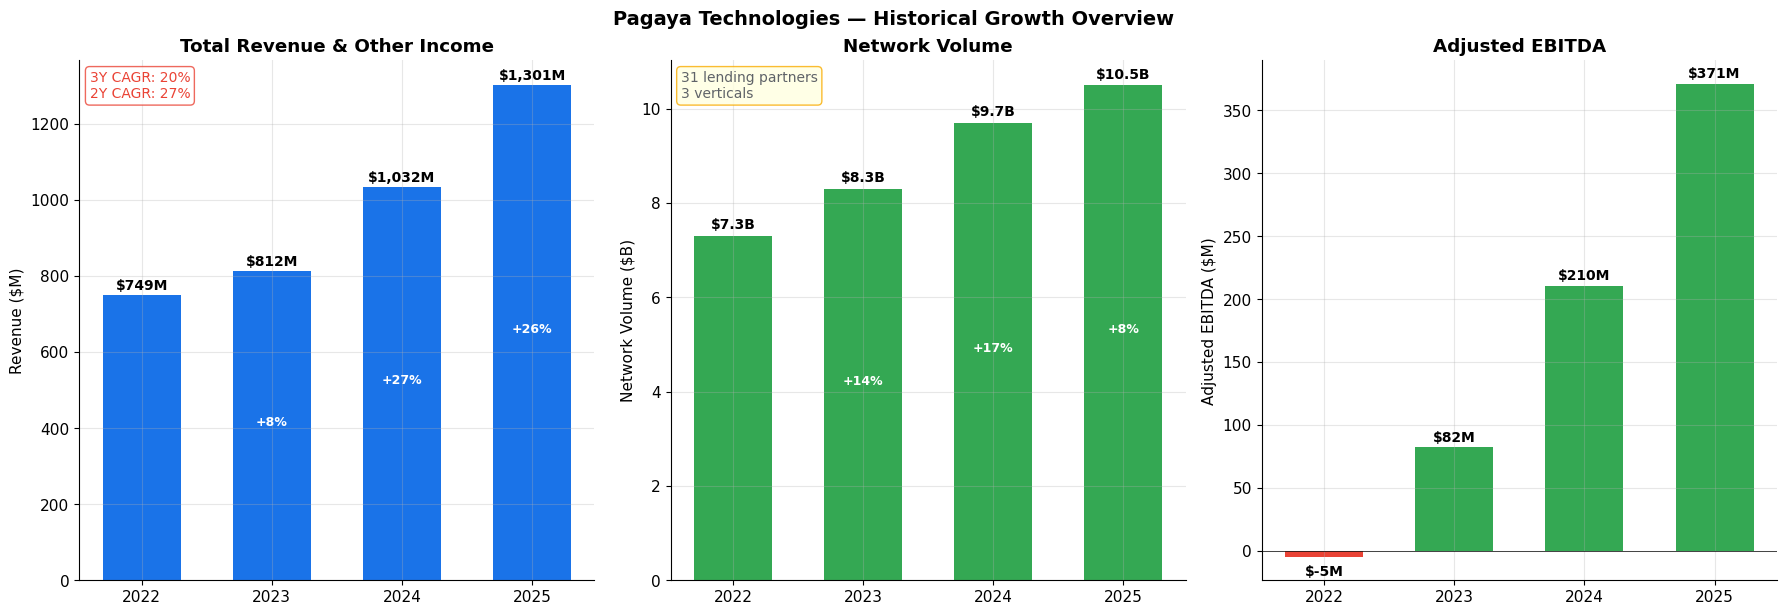

In [8]:
# ============================================================
# CELL GROUP 2: HISTORICAL ANALYSIS — Revenue & Growth
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Revenue growth
years = historical_annual.index.tolist()
revs = historical_annual['Revenue_M'].values
ax = axes[0]
ax.bar(range(len(years)), revs, color=COLORS['primary'], width=0.6)
for i, (y, r) in enumerate(zip(years, revs)):
    ax.text(i, r + 15, f'${r:,.0f}M', ha='center', fontsize=10, fontweight='bold')
    if i > 0 and not np.isnan(historical_annual['YoY_Growth'].iloc[i]):
        g = historical_annual['YoY_Growth'].iloc[i]
        ax.text(i, r/2, f'+{g:.0%}', ha='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel('Revenue ($M)')
ax.set_title('Total Revenue & Other Income', fontweight='bold')

cagr_3yr = (1301 / 748.9) ** (1/3) - 1
cagr_2yr = (1301 / 812.1) ** (1/2) - 1
ax.text(0.02, 0.98, f'3Y CAGR: {cagr_3yr:.0%}\n2Y CAGR: {cagr_2yr:.0%}',
        transform=ax.transAxes, va='top', fontsize=10, color=COLORS['accent'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORS['accent'], alpha=0.8))

# 2) Network volume growth
ax = axes[1]
vol = [7.3, 8.3, 9.7, 10.5]
ax.bar(range(len(years)), vol, color=COLORS['secondary'], width=0.6)
for i, (y, v) in enumerate(zip(years, vol)):
    ax.text(i, v + 0.15, f'${v:.1f}B', ha='center', fontsize=10, fontweight='bold')
    if i > 0:
        g = vol[i] / vol[i-1] - 1
        ax.text(i, v/2, f'+{g:.0%}', ha='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel('Network Volume ($B)')
ax.set_title('Network Volume', fontweight='bold')
ax.text(0.02, 0.98, '31 lending partners\n3 verticals',
        transform=ax.transAxes, va='top', fontsize=10, color=COLORS['neutral'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor=COLORS['gold'], alpha=0.8))

# 3) Adjusted EBITDA
ax = axes[2]
ebitda_vals = historical_annual['Adj_EBITDA_M'].values
colors_bar = [COLORS['accent'] if v < 0 else COLORS['secondary'] for v in ebitda_vals]
ax.bar(range(len(years)), ebitda_vals, color=colors_bar, width=0.6)
for i, (y, e) in enumerate(zip(years, ebitda_vals)):
    offset = 5 if e >= 0 else -15
    ax.text(i, e + offset, f'${e:,.0f}M', ha='center', fontsize=10, fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel('Adjusted EBITDA ($M)')
ax.set_title('Adjusted EBITDA', fontweight='bold')

plt.tight_layout()
plt.suptitle('Pagaya Technologies — Historical Growth Overview', fontsize=14, fontweight='bold', y=1.02)
plt.show()

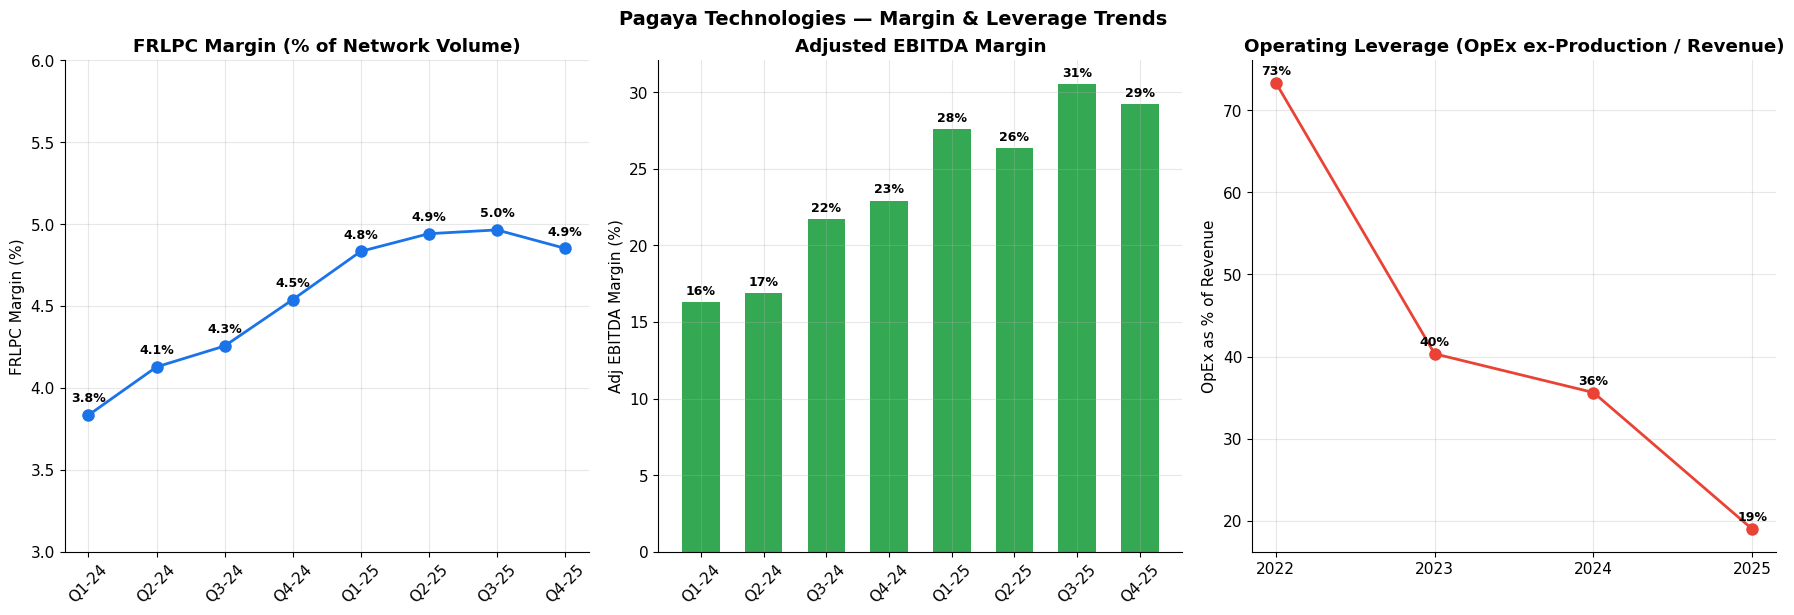

In [9]:
# ── Quarterly Margin & Operating Leverage Analysis ───────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

quarters = quarterly.index.tolist()
x = range(len(quarters))

# 1) FRLPC margin trend
ax = axes[0]
ax.plot(x, quarterly['FRLPC_margin_pct'].values, 'o-', color=COLORS['primary'], linewidth=2, markersize=8)
for i, v in enumerate(quarterly['FRLPC_margin_pct'].values):
    ax.text(i, v + 0.08, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45)
ax.set_ylabel('FRLPC Margin (%)')
ax.set_title('FRLPC Margin (% of Network Volume)', fontweight='bold')
ax.set_ylim(3.0, 6.0)

# 2) Adj EBITDA margin
ax = axes[1]
ax.bar(x, quarterly['EBITDA_margin_pct'].values, color=COLORS['secondary'], width=0.6)
for i, v in enumerate(quarterly['EBITDA_margin_pct'].values):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45)
ax.set_ylabel('Adj EBITDA Margin (%)')
ax.set_title('Adjusted EBITDA Margin', fontweight='bold')

# 3) OpEx ex-production (annual) as % of revenue
ax = axes[2]
opex_pct = (historical_annual['Opex_ex_production'] / historical_annual['Total_revenue'] * 100).values
ax.plot(range(len(years)), opex_pct, 'o-', color=COLORS['accent'], linewidth=2, markersize=8)
for i, v in enumerate(opex_pct):
    ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel('OpEx as % of Revenue')
ax.set_title('Operating Leverage (OpEx ex-Production / Revenue)', fontweight='bold')

plt.tight_layout()
plt.suptitle('Pagaya Technologies — Margin & Leverage Trends', fontsize=14, fontweight='bold', y=1.02)
plt.show()

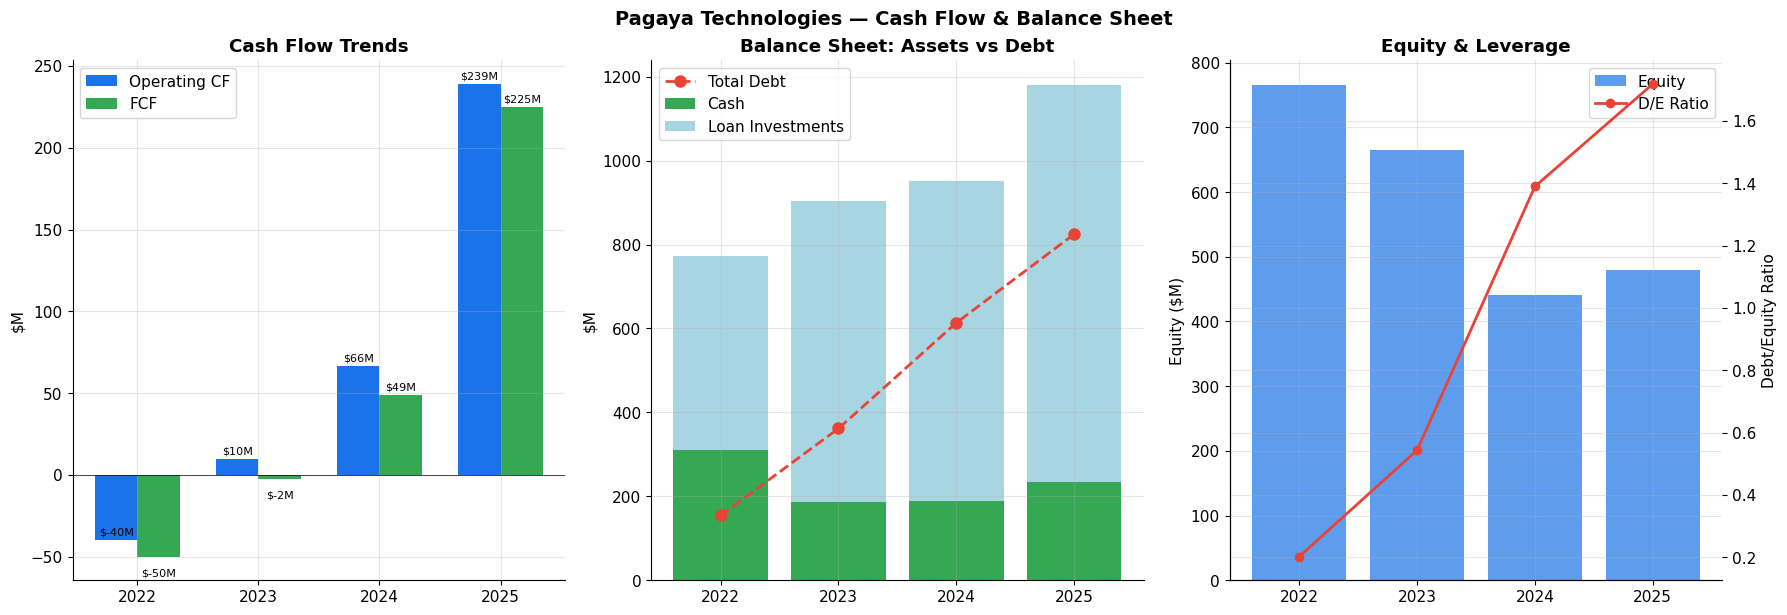

In [10]:
# ── Cash Flow & Balance Sheet Analysis ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Operating Cash Flow & FCF
ax = axes[0]
w = 0.35
ocf = (cashflow['Operating_cashflow'] / 1000).values
fcf = (cashflow['FCF'] / 1000).values
ax.bar([i - w/2 for i in range(len(years))], ocf, w, label='Operating CF', color=COLORS['primary'])
ax.bar([i + w/2 for i in range(len(years))], fcf, w, label='FCF', color=COLORS['secondary'])
for i in range(len(years)):
    ax.text(i - w/2, ocf[i] + 3, f'${ocf[i]:,.0f}M', ha='center', fontsize=8)
    ax.text(i + w/2, fcf[i] + 3 if fcf[i] >= 0 else fcf[i] - 12, f'${fcf[i]:,.0f}M', ha='center', fontsize=8)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel('$M')
ax.set_title('Cash Flow Trends', fontweight='bold')
ax.legend()

# 2) Balance sheet composition
ax = axes[1]
cash_vals = (balance_sheet['Cash_equivalents'] / 1000).values
invest_vals = (balance_sheet['Investments_loans_sec'] / 1000).values
debt_vals = (balance_sheet['Total_debt'] / 1000).values
ax.bar(range(len(years)), cash_vals, label='Cash', color=COLORS['secondary'])
ax.bar(range(len(years)), invest_vals, bottom=cash_vals, label='Loan Investments', color=COLORS['light'])
ax.plot(range(len(years)), debt_vals, 'o--', color=COLORS['accent'], linewidth=2, label='Total Debt', markersize=8)
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel('$M')
ax.set_title('Balance Sheet: Assets vs Debt', fontweight='bold')
ax.legend()

# 3) Equity & leverage
ax = axes[2]
equity = (balance_sheet['Total_equity'] / 1000).values
leverage = balance_sheet['Debt_to_equity'].values
ax2 = ax.twinx()
ax.bar(range(len(years)), equity, color=COLORS['primary'], alpha=0.7, label='Equity')
ax2.plot(range(len(years)), leverage, 'o-', color=COLORS['accent'], linewidth=2, label='D/E Ratio')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel('Equity ($M)')
ax2.set_ylabel('Debt/Equity Ratio')
ax.set_title('Equity & Leverage', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.suptitle('Pagaya Technologies — Cash Flow & Balance Sheet', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Cell Group 3: Bottom-Up Operating Model (2026-2030)

In [11]:
# ============================================================
# CELL GROUP 3: BOTTOM-UP MODEL ASSUMPTIONS
# ============================================================
# Key driver: Network Volume = f(partners, volume/partner, vertical mix)
# Revenue = f(network volume, fee rate)
# FRLPC = Revenue from fees - Production costs

# ── Scenario Assumptions ─────────────────────────────────────
proj_years = [2026, 2027, 2028, 2029, 2030]

assumptions = {
    'Bull': {
        'volume_growth': [0.24, 0.18, 0.15, 0.13, 0.12],   # network volume YoY growth
        'frlpc_margin':  [0.051, 0.053, 0.055, 0.057, 0.060], # FRLPC as % of network volume
        'opex_growth':   [0.05, 0.05, 0.05, 0.04, 0.04],    # cash OpEx ex-production growth
        'capex_pct_rev': [0.010, 0.010, 0.009, 0.009, 0.008],
        'tax_rate':      [0.15, 0.17, 0.18, 0.19, 0.20],
        'sbc_pct_rev':   [0.040, 0.035, 0.030, 0.028, 0.025],
        'retained_int_chg': [-30_000, -25_000, -20_000, -15_000, -10_000], # net change in retained interests
    },
    'Base': {
        'volume_growth': [0.15, 0.12, 0.10, 0.08, 0.07],
        'frlpc_margin':  [0.050, 0.051, 0.052, 0.054, 0.055],
        'opex_growth':   [0.07, 0.07, 0.06, 0.06, 0.05],
        'capex_pct_rev': [0.011, 0.011, 0.010, 0.010, 0.009],
        'tax_rate':      [0.15, 0.17, 0.18, 0.19, 0.20],
        'sbc_pct_rev':   [0.045, 0.040, 0.035, 0.032, 0.030],
        'retained_int_chg': [-30_000, -25_000, -20_000, -15_000, -10_000],
    },
    'Bear': {
        'volume_growth': [0.05, 0.04, 0.04, 0.03, 0.03],
        'frlpc_margin':  [0.049, 0.049, 0.050, 0.050, 0.050],
        'opex_growth':   [0.08, 0.08, 0.07, 0.07, 0.06],
        'capex_pct_rev': [0.012, 0.012, 0.011, 0.011, 0.010],
        'tax_rate':      [0.15, 0.17, 0.18, 0.19, 0.20],
        'sbc_pct_rev':   [0.050, 0.048, 0.045, 0.042, 0.040],
        'retained_int_chg': [-35_000, -30_000, -25_000, -20_000, -15_000],
    },
}

# Base year (FY2025) actuals
base_year = {
    'network_volume': 10_500_000,  # $K (= $10.5B)
    'total_revenue':  1_301_000,
    'frlpc':          512_000,
    'opex_ex_prod':   247_000,     # Tech + S&M + G&A (cash, ex-SBC)
    'adj_ebitda':     371_000,
    'sbc':             60_000,
    'dna':             14_000,
    'interest_exp':    65_000,
    'capex':           14_000,
}

print('Model assumptions loaded for Bull / Base / Bear scenarios.')
print(f"\nBase Year (FY2025):")
for k, v in base_year.items():
    print(f"  {k}: ${v:,}K")

Model assumptions loaded for Bull / Base / Bear scenarios.

Base Year (FY2025):
  network_volume: $10,500,000K
  total_revenue: $1,301,000K
  frlpc: $512,000K
  opex_ex_prod: $247,000K
  adj_ebitda: $371,000K
  sbc: $60,000K
  dna: $14,000K
  interest_exp: $65,000K
  capex: $14,000K


In [12]:
# ── Build Bottom-Up Projections for All Scenarios ────────────

projections = {}

for scenario, params in assumptions.items():
    rows = []
    prev_volume = base_year['network_volume']
    prev_opex = base_year['opex_ex_prod']
    
    for i, year in enumerate(proj_years):
        # Network volume
        volume = prev_volume * (1 + params['volume_growth'][i])
        
        # FRLPC
        frlpc = volume * params['frlpc_margin'][i]
        
        # Revenue estimate: FRLPC / ~0.40 (FRLPC is ~40% of revenue historically)
        # More precisely: revenue = fee_revenue + interest_income + investment_income
        # fee_revenue ~= production_costs + FRLPC; total_revenue ~= fee_revenue * 1.03
        production_costs = volume * (params['frlpc_margin'][i] * 1.5)  # prod costs ~1.5x FRLPC margin
        fee_revenue = production_costs + frlpc
        total_revenue = fee_revenue * 1.03  # ~3% from interest/investment income
        
        # Operating expenses (ex-production, cash)
        opex = prev_opex * (1 + params['opex_growth'][i])
        
        # SBC
        sbc = total_revenue * params['sbc_pct_rev'][i]
        
        # Adjusted EBITDA = FRLPC - cash OpEx ex-production
        adj_ebitda = frlpc - opex
        
        # GAAP Operating Income = Adj EBITDA - SBC - D&A
        dna = 14_000 * (1.05 ** i)  # ~5% growth
        gaap_op_income = adj_ebitda - sbc - dna
        
        # Interest expense (declining as debt is refinanced)
        interest = base_year['interest_exp'] * (0.95 ** i)
        
        # Pre-tax income
        pretax = gaap_op_income - interest
        
        # Tax
        tax = max(0, pretax * params['tax_rate'][i])
        
        # GAAP Net Income
        gaap_ni = pretax - tax
        
        # Capex
        capex = total_revenue * params['capex_pct_rev'][i]
        
        # FCF = Adj EBITDA - cash taxes - capex - retained interest changes
        cash_taxes = tax  # approximate
        fcf = adj_ebitda - cash_taxes - capex + params['retained_int_chg'][i]
        
        rows.append({
            'Year': year,
            'Network_Volume_K': volume,
            'FRLPC_K': frlpc,
            'Total_Revenue_K': total_revenue,
            'Production_Costs_K': production_costs,
            'OpEx_ex_prod_K': opex,
            'SBC_K': sbc,
            'D_A_K': dna,
            'Adj_EBITDA_K': adj_ebitda,
            'GAAP_Op_Income_K': gaap_op_income,
            'Interest_K': interest,
            'Pretax_K': pretax,
            'Tax_K': tax,
            'GAAP_NI_K': gaap_ni,
            'Capex_K': capex,
            'Cash_Tax_K': cash_taxes,
            'Retained_Int_Chg_K': params['retained_int_chg'][i],
            'FCF_K': fcf,
            'FRLPC_margin': params['frlpc_margin'][i],
            'Volume_growth': params['volume_growth'][i],
        })
        
        prev_volume = volume
        prev_opex = opex
    
    projections[scenario] = pd.DataFrame(rows).set_index('Year')

# Display Base case
print('BASE CASE PROJECTIONS ($K):')
base_proj = projections['Base']
display_cols = ['Network_Volume_K', 'Total_Revenue_K', 'FRLPC_K', 'Adj_EBITDA_K', 'GAAP_NI_K', 'FCF_K']
display_df = base_proj[display_cols].copy()
display_df.columns = ['Net Volume', 'Revenue', 'FRLPC', 'Adj EBITDA', 'GAAP NI', 'FCF']
print(display_df.applymap(lambda x: f'${x/1000:,.0f}M').to_string())

print('\n--- Growth Rates ---')
for s in ['Bull', 'Base', 'Bear']:
    rev_cagr = (projections[s].loc[2030, 'Total_Revenue_K'] / base_year['total_revenue']) ** (1/5) - 1
    print(f"{s}: Revenue CAGR = {rev_cagr:.1%}, 2030E Adj EBITDA = ${projections[s].loc[2030, 'Adj_EBITDA_K']/1000:,.0f}M")

BASE CASE PROJECTIONS ($K):
     Net Volume  Revenue  FRLPC Adj EBITDA GAAP NI    FCF
Year                                                     
2026   $12,075M  $1,555M  $604M      $339M   $162M  $264M
2027   $13,524M  $1,776M  $690M      $407M   $215M  $318M
2028   $14,876M  $1,992M  $774M      $474M   $271M  $374M
2029   $16,067M  $2,234M  $868M      $550M   $329M  $435M
2030   $17,191M  $2,435M  $946M      $612M   $375M  $486M

--- Growth Rates ---
Bull: Revenue CAGR = 21.6%, 2030E Adj EBITDA = $1,032M
Base: Revenue CAGR = 13.4%, 2030E Adj EBITDA = $612M
Bear: Revenue CAGR = 4.6%, 2030E Adj EBITDA = $283M


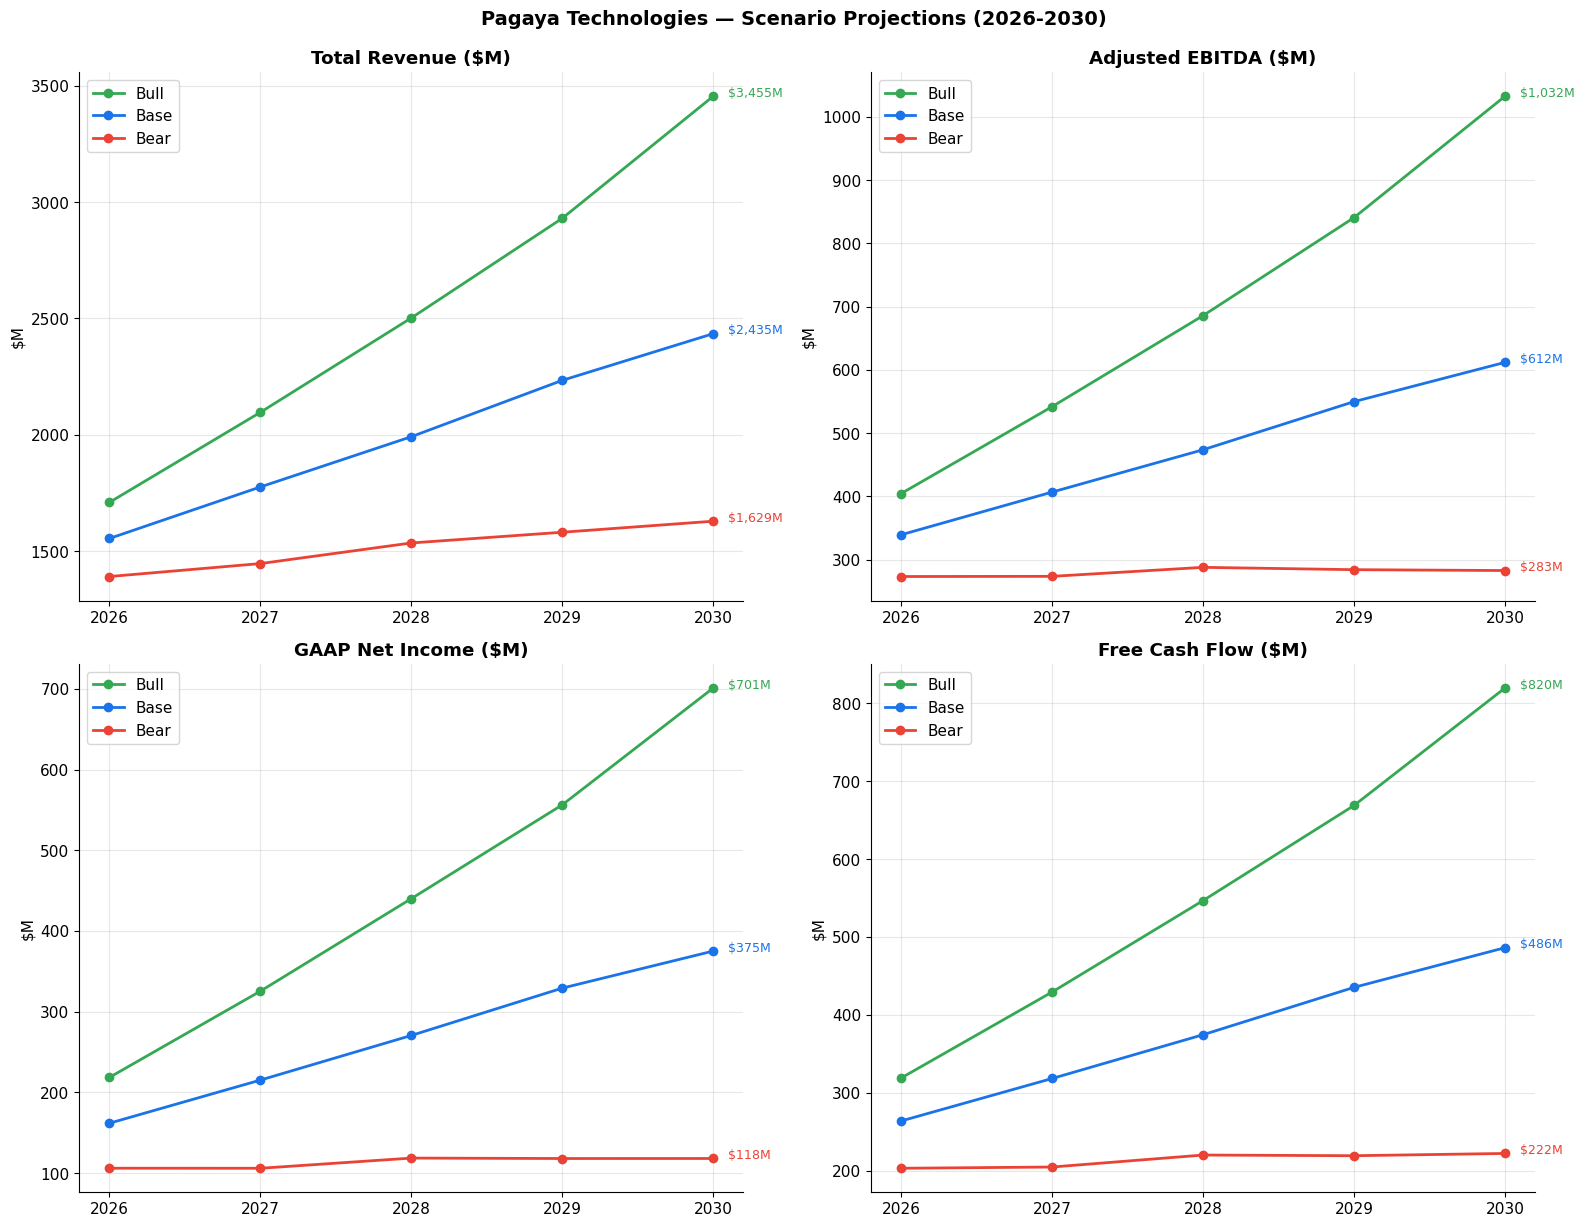

In [13]:
# ── Scenario Comparison Charts ───────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = [
    ('Total_Revenue_K', 'Total Revenue ($M)', 1000),
    ('Adj_EBITDA_K', 'Adjusted EBITDA ($M)', 1000),
    ('GAAP_NI_K', 'GAAP Net Income ($M)', 1000),
    ('FCF_K', 'Free Cash Flow ($M)', 1000),
]

scenario_colors = {'Bull': COLORS['secondary'], 'Base': COLORS['primary'], 'Bear': COLORS['accent']}

for idx, (col, title, div) in enumerate(metrics):
    ax = axes[idx // 2][idx % 2]
    for scenario, color in scenario_colors.items():
        vals = projections[scenario][col].values / div
        ax.plot(proj_years, vals, 'o-', color=color, linewidth=2, label=scenario, markersize=6)
        ax.text(proj_years[-1] + 0.1, vals[-1], f'${vals[-1]:,.0f}M', fontsize=9, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('$M')
    ax.legend()
    ax.set_xticks(proj_years)

plt.tight_layout()
plt.suptitle('Pagaya Technologies — Scenario Projections (2026-2030)', fontsize=14, fontweight='bold', y=1.02)
plt.show()

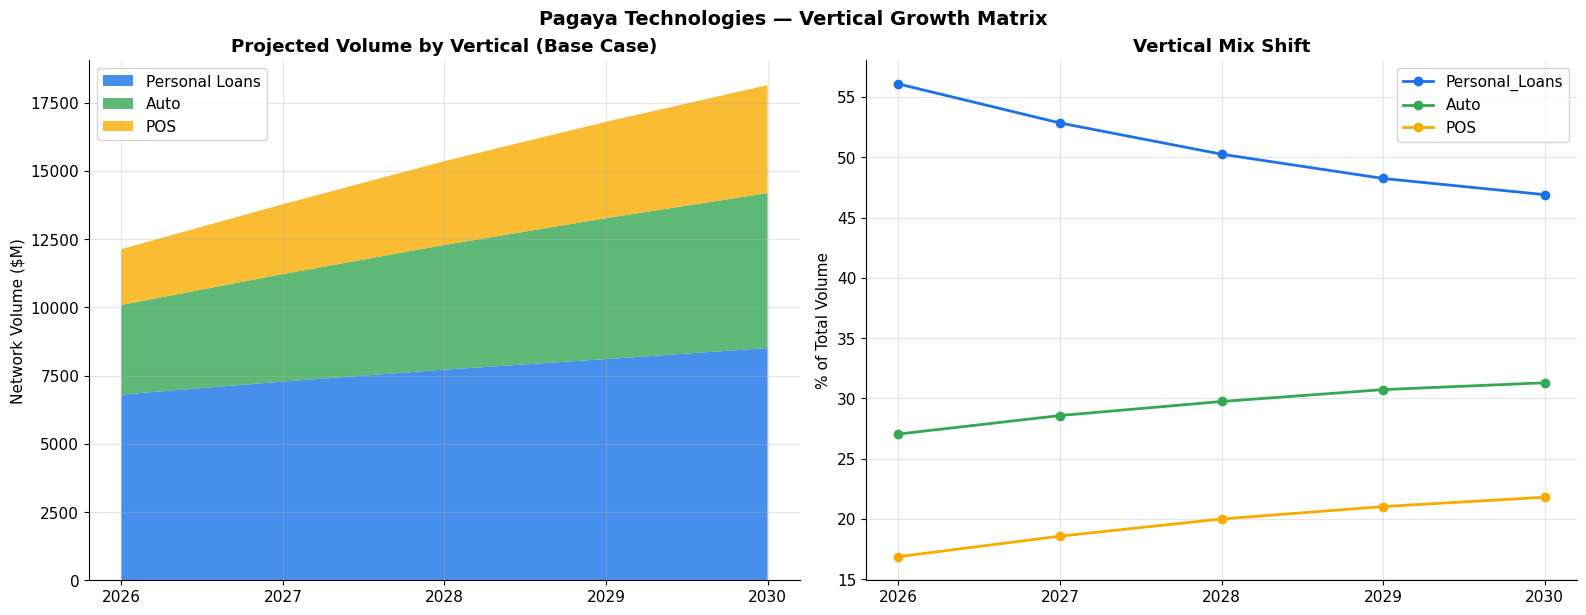


Vertical Volume Projections ($M, Base Case):
      Personal_Loans    Auto     POS    Total
2026          6804.0  3281.0  2048.0  12133.0
2027          7280.0  3938.0  2559.0  13777.0
2028          7717.0  4568.0  3071.0  15356.0
2029          8103.0  5161.0  3532.0  16796.0
2030          8508.0  5677.0  3956.0  18141.0


In [14]:
# ── Vertical Growth Matrix ────────────────────────────────────
# Project volume by vertical for Base case

vertical_assumptions = {
    'Personal_Loans': {
        'base_volume': 6_300_000,  # FY2025 $K
        'growth_rates': [0.08, 0.07, 0.06, 0.05, 0.05],  # maturing vertical
    },
    'Auto': {
        'base_volume': 2_625_000,
        'growth_rates': [0.25, 0.20, 0.16, 0.13, 0.10],  # high growth, scaling
    },
    'POS': {
        'base_volume': 1_575_000,
        'growth_rates': [0.30, 0.25, 0.20, 0.15, 0.12],  # earliest stage, fastest growth
    },
}

vert_proj = {}
for vert, params in vertical_assumptions.items():
    volumes = []
    v = params['base_volume']
    for g in params['growth_rates']:
        v = v * (1 + g)
        volumes.append(v)
    vert_proj[vert] = volumes

vert_df = pd.DataFrame(vert_proj, index=proj_years)
vert_df['Total'] = vert_df.sum(axis=1)
vert_df_M = vert_df / 1000  # convert to $M

# Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked area chart
ax = axes[0]
ax.stackplot(proj_years, 
             vert_df_M['Personal_Loans'].values,
             vert_df_M['Auto'].values,
             vert_df_M['POS'].values,
             labels=['Personal Loans', 'Auto', 'POS'],
             colors=[COLORS['primary'], COLORS['secondary'], COLORS['gold']],
             alpha=0.8)
ax.set_ylabel('Network Volume ($M)')
ax.set_title('Projected Volume by Vertical (Base Case)', fontweight='bold')
ax.legend(loc='upper left')
ax.set_xticks(proj_years)

# Mix shift
ax = axes[1]
for vert, color in zip(['Personal_Loans', 'Auto', 'POS'], 
                        [COLORS['primary'], COLORS['secondary'], COLORS['gold']]):
    mix = (vert_df[vert] / vert_df['Total'] * 100).values
    ax.plot(proj_years, mix, 'o-', color=color, linewidth=2, label=vert)
ax.set_ylabel('% of Total Volume')
ax.set_title('Vertical Mix Shift', fontweight='bold')
ax.legend()
ax.set_xticks(proj_years)

plt.tight_layout()
plt.suptitle('Pagaya Technologies — Vertical Growth Matrix', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Display table
print('\nVertical Volume Projections ($M, Base Case):')
print(vert_df_M.round(0).to_string())

# Cell Group 4: 3-Statement Projected Model (2026-2030)

In [15]:
# ============================================================
# CELL GROUP 4: 3-STATEMENT PROJECTED MODEL (Base Case)
# ============================================================

proj = projections['Base'].copy()

# ── Projected Income Statement ───────────────────────────────
print('=' * 80)
print('PROJECTED INCOME STATEMENT — BASE CASE ($K)')
print('=' * 80)

is_display = proj[['Total_Revenue_K', 'Production_Costs_K', 'FRLPC_K', 
                    'OpEx_ex_prod_K', 'SBC_K', 'D_A_K', 
                    'Adj_EBITDA_K', 'GAAP_Op_Income_K', 'Interest_K',
                    'Pretax_K', 'Tax_K', 'GAAP_NI_K']].copy()

is_display.columns = ['Revenue', 'Prod Costs', 'FRLPC', 'Cash OpEx', 'SBC', 'D&A',
                       'Adj EBITDA', 'GAAP Op Inc', 'Interest', 'Pre-tax', 'Tax', 'Net Income']

# Add historical for context
hist_row_2025 = {
    'Revenue': 1_301_000, 'Prod Costs': 789_000, 'FRLPC': 512_000,
    'Cash OpEx': 247_000, 'SBC': 60_000, 'D&A': 14_000,
    'Adj EBITDA': 371_000, 'GAAP Op Inc': 264_000, 'Interest': 65_000,
    'Pre-tax': 199_000, 'Tax': 30_000, 'Net Income': 81_000
}
is_full = pd.concat([pd.DataFrame(hist_row_2025, index=[2025]), is_display])

print(is_full.applymap(lambda x: f'${x/1000:,.0f}M' if x >= 0 else f'(${abs(x)/1000:,.0f}M)').to_string())

# ── Projected Balance Sheet (simplified) ─────────────────────
print('\n' + '=' * 80)
print('PROJECTED BALANCE SHEET — BASE CASE ($K)')
print('=' * 80)

bs_rows = []
prev_cash = 235_000
prev_investments = 945_000
prev_debt = 825_000
prev_equity = 480_000

for year in proj_years:
    p = proj.loc[year]
    # Cash = prior + FCF (simplified)
    cash = prev_cash + p['FCF_K']
    # Investments decrease as asset-light transition continues
    investments = prev_investments + p['Retained_Int_Chg_K']
    # Debt stays relatively flat (refinanced, not growing)
    debt = prev_debt * 0.98  # slight paydown
    # Equity = prior + NI + SBC (SBC adds to equity via paid-in capital)
    equity = prev_equity + p['GAAP_NI_K'] + p['SBC_K']
    total_assets = cash + investments + 300_000  # other assets ~$300M
    
    bs_rows.append({
        'Year': year, 'Cash': cash, 'Investments': investments,
        'Total_Assets': total_assets, 'Total_Debt': debt, 'Equity': equity,
        'Net_Debt': debt - cash,
    })
    prev_cash = cash
    prev_investments = investments
    prev_debt = debt
    prev_equity = equity

bs_proj = pd.DataFrame(bs_rows).set_index('Year')
print(bs_proj.applymap(lambda x: f'${x/1000:,.0f}M').to_string())

# ── Projected Cash Flow (simplified) ─────────────────────────
print('\n' + '=' * 80)
print('PROJECTED CASH FLOW — BASE CASE ($K)')
print('=' * 80)

cf_display = proj[['Adj_EBITDA_K', 'Cash_Tax_K', 'Capex_K', 'Retained_Int_Chg_K', 'FCF_K']].copy()
cf_display.columns = ['Adj EBITDA', 'Cash Taxes', 'Capex', 'Retained Int Chg', 'FCF']
print(cf_display.applymap(lambda x: f'${x/1000:,.0f}M' if x >= 0 else f'(${abs(x)/1000:,.0f}M)').to_string())

PROJECTED INCOME STATEMENT — BASE CASE ($K)
      Revenue Prod Costs  FRLPC Cash OpEx   SBC   D&A Adj EBITDA GAAP Op Inc Interest Pre-tax   Tax Net Income
2025  $1,301M      $789M  $512M     $247M  $60M  $14M      $371M       $264M     $65M   $199M  $30M       $81M
2026  $1,555M      $906M  $604M     $264M  $70M  $14M      $339M       $256M     $65M   $191M  $29M      $162M
2027  $1,776M    $1,035M  $690M     $283M  $71M  $15M      $407M       $321M     $62M   $259M  $44M      $215M
2028  $1,992M    $1,160M  $774M     $300M  $70M  $15M      $474M       $389M     $59M   $330M  $59M      $271M
2029  $2,234M    $1,301M  $868M     $318M  $71M  $16M      $550M       $462M     $56M   $406M  $77M      $329M
2030  $2,435M    $1,418M  $946M     $334M  $73M  $17M      $612M       $522M     $53M   $469M  $94M      $375M

PROJECTED BALANCE SHEET — BASE CASE ($K)
         Cash Investments Total_Assets Total_Debt   Equity  Net_Debt
Year                                                                

In [16]:
# ── Balance Sheet & Cash Flow Verification ───────────────────

print('VERIFICATION CHECKS:')
print('-' * 50)

# Check 1: Assets = Liabilities + Equity (rough)
for year in proj_years:
    row = bs_proj.loc[year]
    implied_liabilities = row['Total_Assets'] - row['Equity']
    print(f"{year}: Assets ${row['Total_Assets']/1000:,.0f}M = Equity ${row['Equity']/1000:,.0f}M + Implied Liab ${implied_liabilities/1000:,.0f}M")

# Check 2: Cash balance accumulation
print('\nCash Balance Accumulation:')
print(f"FY2025: ${235_000/1000:,.0f}M (actual)")
for year in proj_years:
    print(f"FY{year}: ${bs_proj.loc[year, 'Cash']/1000:,.0f}M")

# Check 3: FCF yield
diluted_shares = 102_000  # 102M shares
stock_price = 11.49
market_cap = diluted_shares * stock_price  # $K
print(f"\nFCF Yield on Current Market Cap (${market_cap/1000:,.0f}M):")
for year in proj_years:
    fcf = proj.loc[year, 'FCF_K']
    fcf_yield = fcf / market_cap * 100
    print(f"  FY{year}: ${fcf/1000:,.0f}M FCF -> {fcf_yield:.1f}% yield")

VERIFICATION CHECKS:
--------------------------------------------------
2026: Assets $1,714M = Equity $712M + Implied Liab $1,002M
2027: Assets $2,007M = Equity $998M + Implied Liab $1,009M
2028: Assets $2,362M = Equity $1,339M + Implied Liab $1,023M
2029: Assets $2,782M = Equity $1,739M + Implied Liab $1,043M
2030: Assets $3,258M = Equity $2,187M + Implied Liab $1,071M

Cash Balance Accumulation:
FY2025: $235M (actual)
FY2026: $499M
FY2027: $817M
FY2028: $1,192M
FY2029: $1,627M
FY2030: $2,113M

FCF Yield on Current Market Cap ($1,172M):
  FY2026: $264M FCF -> 22.5% yield
  FY2027: $318M FCF -> 27.2% yield
  FY2028: $374M FCF -> 32.0% yield
  FY2029: $435M FCF -> 37.1% yield
  FY2030: $486M FCF -> 41.5% yield


# Cell Group 5: DCF Valuation

In [17]:
# ============================================================
# CELL GROUP 5: DCF VALUATION
# ============================================================

def dcf_valuation(fcf_series, wacc, terminal_growth, net_debt, diluted_shares_K):
    """
    5-year DCF with Gordon Growth terminal value.
    
    Args:
        fcf_series: dict {year: fcf_in_thousands}
        wacc: weighted average cost of capital (decimal)
        terminal_growth: perpetuity growth rate (decimal)
        net_debt: net debt in thousands (positive = net debt)
        diluted_shares_K: diluted shares in thousands
    
    Returns:
        dict with valuation components
    """
    years = sorted(fcf_series.keys())
    base_year_offset = years[0] - 1  # discount from base year
    
    # PV of projected FCFs
    pv_fcfs = 0
    for y in years:
        n = y - base_year_offset
        pv = fcf_series[y] / (1 + wacc) ** n
        pv_fcfs += pv
    
    # Terminal value (Gordon Growth)
    terminal_fcf = fcf_series[years[-1]] * (1 + terminal_growth)
    terminal_value = terminal_fcf / (wacc - terminal_growth)
    n_terminal = years[-1] - base_year_offset
    pv_terminal = terminal_value / (1 + wacc) ** n_terminal
    
    # Enterprise value
    ev = pv_fcfs + pv_terminal
    
    # Equity value
    equity_value = ev - net_debt
    
    # Per share
    price_per_share = equity_value / diluted_shares_K  # both in $K -> cancels out
    
    return {
        'pv_fcfs': pv_fcfs,
        'pv_terminal': pv_terminal,
        'terminal_value': terminal_value,
        'ev': ev,
        'equity_value': equity_value,
        'price_per_share': price_per_share,
        'tv_pct': pv_terminal / ev * 100,
    }


# ── Run DCF for all scenarios ────────────────────────────────
wacc = 0.13
terminal_growth = 0.03
net_debt = 590_000  # $590M net debt
diluted_shares = 102_000  # 102M shares (in thousands for consistency)

print('=' * 80)
print('DCF VALUATION RESULTS')
print('=' * 80)
print(f'WACC: {wacc:.1%} | Terminal Growth: {terminal_growth:.1%} | Net Debt: ${net_debt/1000:,.0f}M')
print(f'Diluted Shares: {diluted_shares/1000:.1f}M')
print()

dcf_results = {}
for scenario in ['Bull', 'Base', 'Bear']:
    fcf_dict = {y: projections[scenario].loc[y, 'FCF_K'] for y in proj_years}
    result = dcf_valuation(fcf_dict, wacc, terminal_growth, net_debt, diluted_shares)
    dcf_results[scenario] = result
    
    print(f'--- {scenario} Case ---')
    print(f'  PV of FCFs (2026-2030): ${result["pv_fcfs"]/1000:,.0f}M')
    print(f'  PV of Terminal Value:    ${result["pv_terminal"]/1000:,.0f}M ({result["tv_pct"]:.0f}% of EV)')
    print(f'  Enterprise Value:        ${result["ev"]/1000:,.0f}M')
    print(f'  - Net Debt:              ${net_debt/1000:,.0f}M')
    print(f'  Equity Value:            ${result["equity_value"]/1000:,.0f}M')
    print(f'  Implied Price/Share:     ${result["price_per_share"]:.2f}')
    print(f'  vs Current ($11.49):     {(result["price_per_share"]/11.49 - 1)*100:+.0f}%')
    print()

# Summary table
print('\nSCENARIO SUMMARY:')
summary_data = []
for s in ['Bull', 'Base', 'Bear']:
    p = projections[s]
    summary_data.append({
        'Scenario': s,
        'Implied Price': f'${dcf_results[s]["price_per_share"]:.2f}',
        'Upside': f'{(dcf_results[s]["price_per_share"]/11.49 - 1)*100:+.0f}%',
        '2030E Rev ($M)': f'${p.loc[2030, "Total_Revenue_K"]/1000:,.0f}',
        '2030E EBITDA ($M)': f'${p.loc[2030, "Adj_EBITDA_K"]/1000:,.0f}',
        'Rev CAGR': f'{(p.loc[2030, "Total_Revenue_K"] / base_year["total_revenue"]) ** (1/5) - 1:.1%}',
    })
print(pd.DataFrame(summary_data).set_index('Scenario').to_string())

DCF VALUATION RESULTS
WACC: 13.0% | Terminal Growth: 3.0% | Net Debt: $590M
Diluted Shares: 102.0M

--- Bull Case ---
  PV of FCFs (2026-2030): $1,852M
  PV of Terminal Value:    $4,582M (71% of EV)
  Enterprise Value:        $6,434M
  - Net Debt:              $590M
  Equity Value:            $5,844M
  Implied Price/Share:     $57.29
  vs Current ($11.49):     +399%

--- Base Case ---
  PV of FCFs (2026-2030): $1,273M
  PV of Terminal Value:    $2,718M (68% of EV)
  Enterprise Value:        $3,991M
  - Net Debt:              $590M
  Equity Value:            $3,401M
  Implied Price/Share:     $33.34
  vs Current ($11.49):     +190%

--- Bear Case ---
  PV of FCFs (2026-2030): $747M
  PV of Terminal Value:    $1,241M (62% of EV)
  Enterprise Value:        $1,989M
  - Net Debt:              $590M
  Equity Value:            $1,399M
  Implied Price/Share:     $13.71
  vs Current ($11.49):     +19%


SCENARIO SUMMARY:
         Implied Price Upside 2030E Rev ($M) 2030E EBITDA ($M) Rev CAGR
Sc

# Cell Group 6: Sensitivity Analysis & Output

PRICE SENSITIVITY: WACC vs Terminal Growth Rate
(Base Case FCFs, Implied Share Price)
       2.0%   2.5%   3.0%   3.5%   4.0%
WACC                                   
10%   45.51  48.23  51.33  54.91  59.08
11%   39.46  41.51  43.82  46.44  49.43
12%   34.63  36.22  38.00  39.98  42.20
13%   30.69  31.95  33.34  34.88  36.59
14%   27.41  28.43  29.55  30.77  32.11
15%   24.64  25.48  26.39  27.38  28.45
16%   22.28  22.97  23.72  24.53  25.41

Current price: $11.49
Base case (13% WACC, 3.0% TG): $33.34


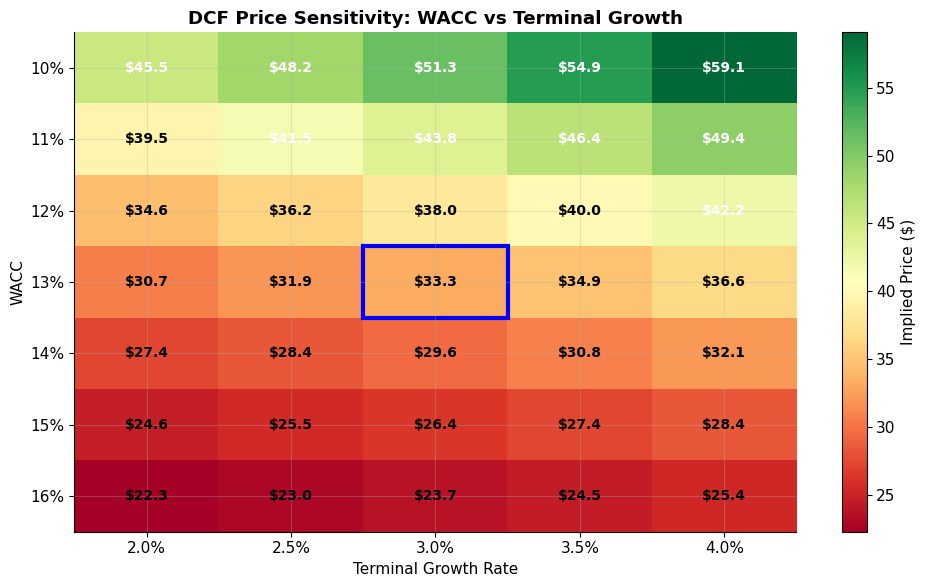

In [18]:
# ============================================================
# CELL GROUP 6: SENSITIVITY ANALYSIS
# ============================================================

# ── 1) WACC vs Terminal Growth Sensitivity ───────────────────

wacc_range = [0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16]
tg_range = [0.020, 0.025, 0.030, 0.035, 0.040]

# Use Base case FCFs
base_fcfs = {y: projections['Base'].loc[y, 'FCF_K'] for y in proj_years}

sensitivity_matrix = []
for w in wacc_range:
    row = []
    for tg in tg_range:
        result = dcf_valuation(base_fcfs, w, tg, net_debt, diluted_shares)
        row.append(round(result['price_per_share'], 2))
    sensitivity_matrix.append(row)

sens_df = pd.DataFrame(sensitivity_matrix,
                        index=[f'{w:.0%}' for w in wacc_range],
                        columns=[f'{tg:.1%}' for tg in tg_range])
sens_df.index.name = 'WACC'

print('PRICE SENSITIVITY: WACC vs Terminal Growth Rate')
print('(Base Case FCFs, Implied Share Price)')
print('=' * 60)
print(sens_df.to_string())
print(f'\nCurrent price: $11.49')
print(f'Base case (13% WACC, 3.0% TG): ${sens_df.loc["13%", "3.0%"]}')

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
data = sens_df.values.astype(float)
im = ax.imshow(data, cmap='RdYlGn', aspect='auto')

ax.set_xticks(range(len(tg_range)))
ax.set_xticklabels([f'{tg:.1%}' for tg in tg_range])
ax.set_yticks(range(len(wacc_range)))
ax.set_yticklabels([f'{w:.0%}' for w in wacc_range])
ax.set_xlabel('Terminal Growth Rate')
ax.set_ylabel('WACC')
ax.set_title('DCF Price Sensitivity: WACC vs Terminal Growth', fontweight='bold')

for i in range(len(wacc_range)):
    for j in range(len(tg_range)):
        val = data[i, j]
        color = 'white' if val < 15 or val > 40 else 'black'
        ax.text(j, i, f'${val:.1f}', ha='center', va='center', fontsize=10, fontweight='bold', color=color)

# Highlight base case cell
base_i = wacc_range.index(0.13)
base_j = tg_range.index(0.030)
rect = plt.Rectangle((base_j - 0.5, base_i - 0.5), 1, 1, fill=False, edgecolor='blue', linewidth=3)
ax.add_patch(rect)

plt.colorbar(im, label='Implied Price ($)')
plt.tight_layout()
plt.show()

In [19]:
# ── 2) Scenario Summary & Peer Comparison ────────────────────

print('=' * 80)
print('VALUATION TRIANGULATION')
print('=' * 80)

# Exit multiple valuation (2030E, discounted at 13% for 5 years)
discount_factor = (1.13) ** 5

print('\n1. DCF (Gordon Growth Terminal Value):')
for s in ['Bull', 'Base', 'Bear']:
    print(f'   {s}: ${dcf_results[s]["price_per_share"]:.2f}')

print('\n2. EV/EBITDA Exit Multiple (2030E, discounted to present):')
ev_ebitda_multiples = [6, 8, 10, 12, 15]
for s in ['Bull', 'Base', 'Bear']:
    ebitda_2030 = projections[s].loc[2030, 'Adj_EBITDA_K']
    print(f'   {s} (2030E EBITDA: ${ebitda_2030/1000:,.0f}M):')
    for mult in ev_ebitda_multiples:
        ev_2030 = ebitda_2030 * mult
        equity_2030 = ev_2030 - net_debt
        price_2030 = equity_2030 / diluted_shares
        price_today = price_2030 / discount_factor
        print(f'     {mult}x: ${price_today:.2f}')

print('\n3. P/E Exit Multiple (2030E, discounted to present):')
pe_multiples = [10, 15, 20, 25, 30]
for s in ['Bull', 'Base', 'Bear']:
    ni_2030 = projections[s].loc[2030, 'GAAP_NI_K']
    print(f'   {s} (2030E NI: ${ni_2030/1000:,.0f}M):')
    for mult in pe_multiples:
        equity_2030 = ni_2030 * mult
        price_2030 = equity_2030 / diluted_shares
        price_today = price_2030 / discount_factor
        print(f'     {mult}x: ${price_today:.2f}')

# ── Peer Comparison ──────────────────────────────────────────
print('\n' + '=' * 80)
print('PEER COMPARISON')
print('=' * 80)

peers = pd.DataFrame({
    'Company': ['PGY (Pagaya)', 'UPST (Upstart)', 'AFRM (Affirm)', 'LC (LendingClub)', 'SOFI (SoFi)'],
    'Model': ['B2B AI Platform', 'AI Marketplace', 'Consumer BNPL', 'Marketplace Lender', 'Digital Bank'],
    'LTM_Rev_M': [1_301, 700, 2_800, 1_300, 3_500],
    'Rev_Growth': ['26%', '63%', '35%', '18%', '36%'],
    'Mkt_Cap_M': [948, 4_500, 24_700, 2_000, 14_000],
    'EV_Rev': ['1.2x', '6.5x', '8.5x', '1.5x', '4.0x'],
    'EV_EBITDA': ['2.6x', '13x', '16x', '6x', '15x'],
})
print(peers.to_string(index=False))

VALUATION TRIANGULATION

1. DCF (Gordon Growth Terminal Value):
   Bull: $57.29
   Base: $33.34
   Bear: $13.71

2. EV/EBITDA Exit Multiple (2030E, discounted to present):
   Bull (2030E EBITDA: $1,032M):
     6x: $29.82
     8x: $40.81
     10x: $51.80
     12x: $62.78
     15x: $79.26
   Base (2030E EBITDA: $612M):
     6x: $16.40
     8x: $22.91
     10x: $29.42
     12x: $35.93
     15x: $45.70
   Bear (2030E EBITDA: $283M):
     6x: $5.89
     8x: $8.90
     10x: $11.91
     12x: $14.93
     15x: $19.44

3. P/E Exit Multiple (2030E, discounted to present):
   Bull (2030E NI: $701M):
     10x: $37.29
     15x: $55.94
     20x: $74.59
     25x: $93.23
     30x: $111.88
   Base (2030E NI: $375M):
     10x: $19.96
     15x: $29.94
     20x: $39.92
     25x: $49.90
     30x: $59.88
   Bear (2030E NI: $118M):
     10x: $6.29
     15x: $9.44
     20x: $12.58
     25x: $15.73
     30x: $18.87

PEER COMPARISON
         Company              Model  LTM_Rev_M Rev_Growth  Mkt_Cap_M EV_Rev EV_E

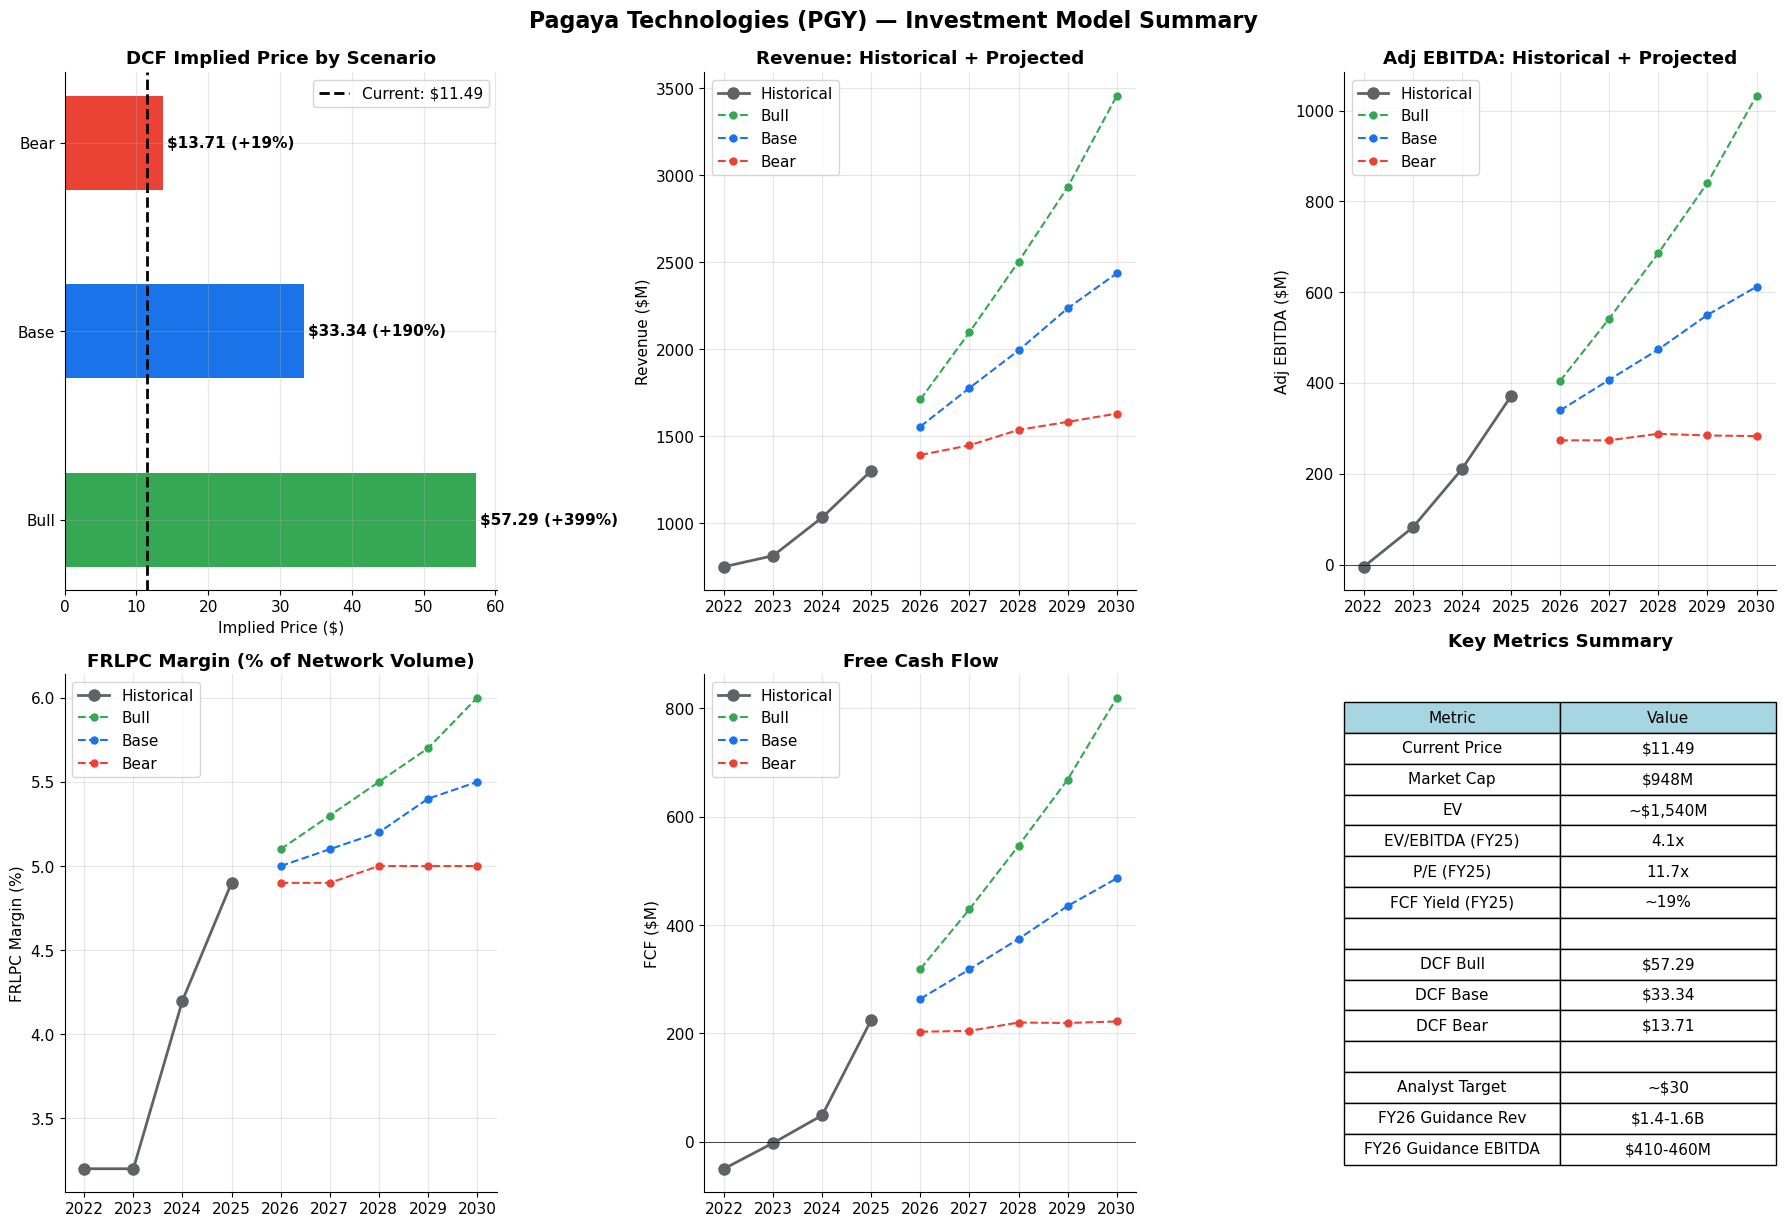


MODEL COMPLETE
Base Case DCF: $33.34 (+190% vs current)
Range: $13.71 (Bear) — $57.29 (Bull)
Current Price: $11.49 | Analyst Consensus: ~$30


In [20]:
# ── 3) Key Metrics Dashboard & Final Output ──────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1) Valuation scenario comparison
ax = axes[0][0]
scenarios = ['Bull', 'Base', 'Bear']
prices = [dcf_results[s]['price_per_share'] for s in scenarios]
colors = [COLORS['secondary'], COLORS['primary'], COLORS['accent']]
bars = ax.barh(scenarios, prices, color=colors, height=0.5)
ax.axvline(x=11.49, color='black', linewidth=2, linestyle='--', label=f'Current: $11.49')
for i, (s, p) in enumerate(zip(scenarios, prices)):
    ax.text(p + 0.5, i, f'${p:.2f} ({(p/11.49-1)*100:+.0f}%)', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Implied Price ($)')
ax.set_title('DCF Implied Price by Scenario', fontweight='bold')
ax.legend()

# 2) Revenue trajectory
ax = axes[0][1]
hist_years = [2022, 2023, 2024, 2025]
hist_rev = [748.9, 812.1, 1032.2, 1301]
ax.plot(hist_years, hist_rev, 'o-', color=COLORS['neutral'], linewidth=2, label='Historical', markersize=8)
for s, color in zip(scenarios, colors):
    proj_rev = (projections[s]['Total_Revenue_K'] / 1000).values
    ax.plot(proj_years, proj_rev, 'o--', color=color, linewidth=1.5, label=s, markersize=5)
ax.set_ylabel('Revenue ($M)')
ax.set_title('Revenue: Historical + Projected', fontweight='bold')
ax.legend()

# 3) EBITDA trajectory
ax = axes[0][2]
hist_ebitda = [-4.8, 82, 210.4, 371]
ax.plot(hist_years, hist_ebitda, 'o-', color=COLORS['neutral'], linewidth=2, label='Historical', markersize=8)
for s, color in zip(scenarios, colors):
    proj_ebitda = (projections[s]['Adj_EBITDA_K'] / 1000).values
    ax.plot(proj_years, proj_ebitda, 'o--', color=color, linewidth=1.5, label=s, markersize=5)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Adj EBITDA ($M)')
ax.set_title('Adj EBITDA: Historical + Projected', fontweight='bold')
ax.legend()

# 4) FRLPC margin evolution
ax = axes[1][0]
hist_frlpc_m = [3.2, 3.2, 4.2, 4.9]
ax.plot(hist_years, hist_frlpc_m, 'o-', color=COLORS['neutral'], linewidth=2, label='Historical', markersize=8)
for s, color in zip(scenarios, colors):
    proj_frlpc_m = [projections[s].loc[y, 'FRLPC_margin'] * 100 for y in proj_years]
    ax.plot(proj_years, proj_frlpc_m, 'o--', color=color, linewidth=1.5, label=s, markersize=5)
ax.set_ylabel('FRLPC Margin (%)')
ax.set_title('FRLPC Margin (% of Network Volume)', fontweight='bold')
ax.legend()

# 5) FCF trajectory
ax = axes[1][1]
hist_fcf = [-50, -2.4, 48.8, 225]
ax.plot(hist_years, hist_fcf, 'o-', color=COLORS['neutral'], linewidth=2, label='Historical', markersize=8)
for s, color in zip(scenarios, colors):
    proj_fcf = (projections[s]['FCF_K'] / 1000).values
    ax.plot(proj_years, proj_fcf, 'o--', color=color, linewidth=1.5, label=s, markersize=5)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('FCF ($M)')
ax.set_title('Free Cash Flow', fontweight='bold')
ax.legend()

# 6) Key metrics table
ax = axes[1][2]
ax.axis('off')
table_data = [
    ['Current Price', '$11.49'],
    ['Market Cap', '$948M'],
    ['EV', '~$1,540M'],
    ['EV/EBITDA (FY25)', '4.1x'],
    ['P/E (FY25)', '11.7x'],
    ['FCF Yield (FY25)', '~19%'],
    ['', ''],
    ['DCF Bull', f'${dcf_results["Bull"]["price_per_share"]:.2f}'],
    ['DCF Base', f'${dcf_results["Base"]["price_per_share"]:.2f}'],
    ['DCF Bear', f'${dcf_results["Bear"]["price_per_share"]:.2f}'],
    ['', ''],
    ['Analyst Target', '~$30'],
    ['FY26 Guidance Rev', '$1.4-1.6B'],
    ['FY26 Guidance EBITDA', '$410-460M'],
]
table = ax.table(cellText=table_data, colLabels=['Metric', 'Value'],
                  cellLoc='center', loc='center',
                  colColours=[COLORS['light'], COLORS['light']])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)
ax.set_title('Key Metrics Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.suptitle('Pagaya Technologies (PGY) — Investment Model Summary', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print('\n' + '=' * 80)
print('MODEL COMPLETE')
print('=' * 80)
print(f'Base Case DCF: ${dcf_results["Base"]["price_per_share"]:.2f} ({(dcf_results["Base"]["price_per_share"]/11.49-1)*100:+.0f}% vs current)')
print(f'Range: ${dcf_results["Bear"]["price_per_share"]:.2f} (Bear) — ${dcf_results["Bull"]["price_per_share"]:.2f} (Bull)')
print(f'Current Price: $11.49 | Analyst Consensus: ~$30')